Charger les données et le modèle

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

# Initialiser SHAP
shap.initjs()

print(f"SHAP version : {shap.__version__}")
print("Librairies chargées !")

SHAP version : 0.51.0
Librairies chargées !


 Charger le modèle et les données

In [4]:
# Charger le modèle Random Forest
rf = joblib.load('../models/random_forest_churn.pkl')

# Charger les features
features = pd.read_csv('../data/processed/features_churn.csv')

FEATURE_COLS = [
    'Frequency', 'Monetary', 'Avg_OrderValue',
    'Nb_Produits', 'Avg_Quantity', 'Nb_Jours_Actif',
    'Total_Items', 'Cadence', 'Panier_Moyen'
]

X = features[FEATURE_COLS]
y = features['Churn']

print(f"Modèle chargé : Random Forest")
print(f"Dataset       : {X.shape[0]:,} clients | {X.shape[1]} features")
print(f"Taux churn    : {y.mean()*100:.1f}%")

Modèle chargé : Random Forest
Dataset       : 4,338 clients | 9 features
Taux churn    : 33.4%


Calculer les valeurs SHAP

 Créer l'explainer SHAP

In [5]:
# TreeExplainer est optimisé pour Random Forest
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)

# Pour la classe Churné (classe 1)
shap_values_churn = shap_values[1]

print(f"Valeurs SHAP calculées !")
print(f"   Shape : {shap_values_churn.shape}")
print(f"   Une valeur SHAP par client par feature")

Valeurs SHAP calculées !
   Shape : (9, 2)
   Une valeur SHAP par client par feature


In [6]:
# Nouvelle syntaxe SHAP 0.50+
explainer = shap.TreeExplainer(rf)
shap_explanation = explainer(X)

# Extraire les valeurs pour la classe Churné (index 1)
shap_values_churn = shap_explanation.values[:, :, 1]

print(f"Valeurs SHAP calculées !")
print(f"   Shape attendu  : ({len(X)}, {len(FEATURE_COLS)})")
print(f"   Shape obtenu   : {shap_values_churn.shape}")

# Vérification
assert shap_values_churn.shape == (len(X), len(FEATURE_COLS)), \
    "Shape incorrect — contacte-moi !"
print("Shape correct, on peut continuer !")

Valeurs SHAP calculées !
   Shape attendu  : (4338, 9)
   Shape obtenu   : (4338, 9)
Shape correct, on peut continuer !


C'est quoi une valeur SHAP ?

In [7]:
client_idx = 0
client = X.iloc[client_idx]

print(f"EXEMPLE — Client {features['CustomerID'].iloc[client_idx]:.0f}")
print(f"Churn réel    : {'Churné' if y.iloc[client_idx]==1 else 'Actif'}")
print(f"Score prédit  : {rf.predict_proba(X.iloc[[client_idx]])[0][1]:.2%}")
print()
print("Contribution de chaque feature :")
for feat, shap_val, feat_val in zip(
    FEATURE_COLS,
    shap_values_churn[client_idx],
    client.values
):
    direction = "↑ pousse vers Churn" if shap_val > 0 else "↓ pousse vers Actif"
    print(f"  {feat:<20} = {feat_val:>10.2f} | SHAP = {shap_val:+.4f} {direction}")

EXEMPLE — Client 12346
Churn réel    : Churné
Score prédit  : 42.98%

Contribution de chaque feature :
  Frequency            =       1.00 | SHAP = +0.0364 ↑ pousse vers Churn
  Monetary             =   77183.60 | SHAP = -0.0739 ↓ pousse vers Actif
  Avg_OrderValue       =   77183.60 | SHAP = +0.0130 ↑ pousse vers Churn
  Nb_Produits          =       1.00 | SHAP = +0.0725 ↑ pousse vers Churn
  Avg_Quantity         =   74215.00 | SHAP = +0.0495 ↑ pousse vers Churn
  Nb_Jours_Actif       =       0.00 | SHAP = +0.0617 ↑ pousse vers Churn
  Total_Items          =   74215.00 | SHAP = -0.0554 ↓ pousse vers Actif
  Cadence              =       1.00 | SHAP = +0.0240 ↑ pousse vers Churn
  Panier_Moyen         =   77183.60 | SHAP = -0.0325 ↓ pousse vers Actif


Summary Plots

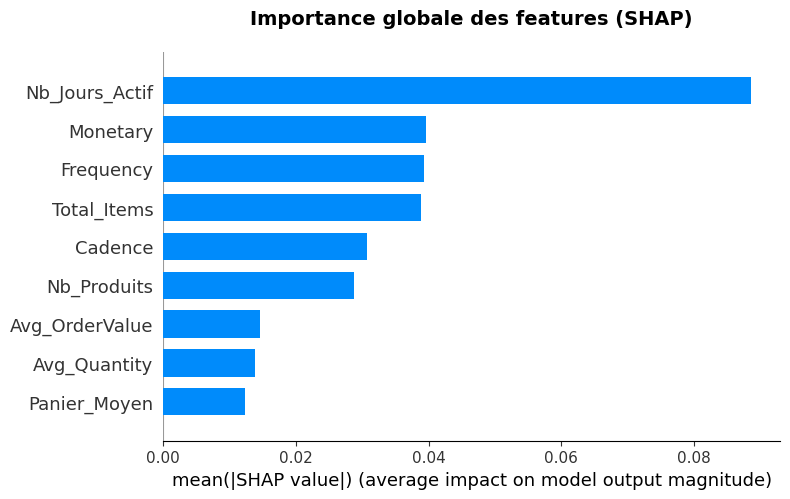

In [8]:
#Importance globale (bar chart)
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values_churn, X,
    plot_type="bar",
    feature_names=FEATURE_COLS,
    show=False
)
plt.title("Importance globale des features (SHAP)",
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../reports/figures/shape_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

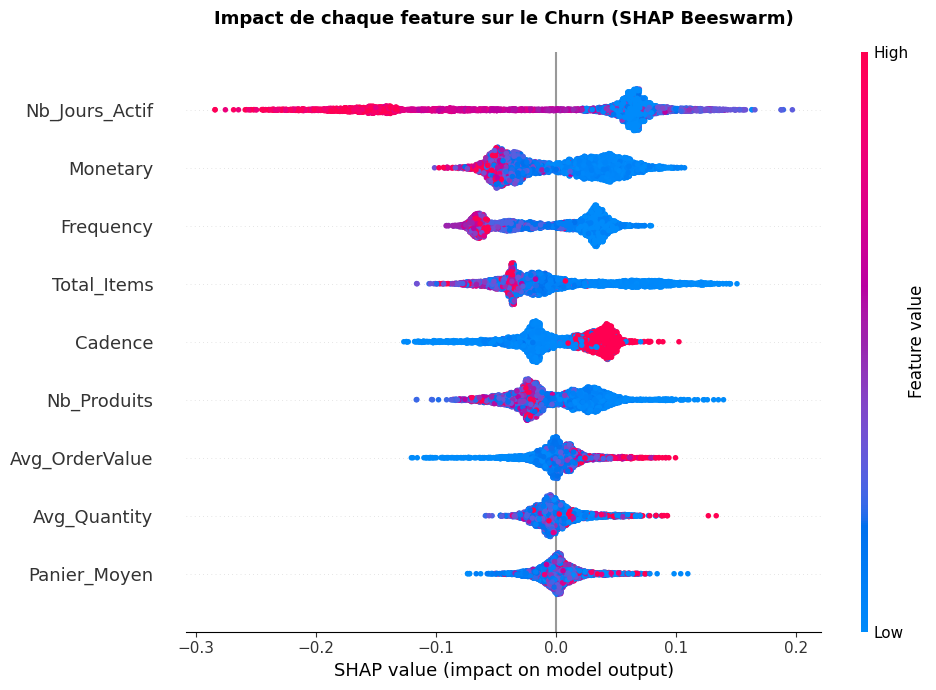

In [9]:
#Beeswarm détaillé
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values_churn, X,
    feature_names=FEATURE_COLS,
    show=False,
    plot_size=(10, 7)
)
plt.title("Impact de chaque feature sur le Churn (SHAP Beeswarm)",
          fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../reports/figures/shape_beeswarm.png',
            dpi=150, bbox_inches='tight')
plt.show()

Waterfall Plots

In [10]:
#Identifier les 3 clients représentatifs
high_risk_idx  = features[features['Churn_Score'] > 0.8].index[0]
low_risk_idx   = features[features['Churn_Score'] < 0.1].index[0]
medium_risk_idx = features[
    (features['Churn_Score'] > 0.45) &
    (features['Churn_Score'] < 0.55)
].index[0]

for label, idx in [("HAUT RISQUE",   high_risk_idx),
                    ("FAIBLE RISQUE", low_risk_idx),
                    ("RISQUE MOYEN",  medium_risk_idx)]:
    score = features['Churn_Score'].iloc[idx]
    cid   = features['CustomerID'].iloc[idx]
    print(f"{label} → Client {cid:.0f} | Score = {score:.2%}")

HAUT RISQUE → Client 12353 | Score = 83.26%
FAIBLE RISQUE → Client 12347 | Score = 0.02%
RISQUE MOYEN → Client 12384 | Score = 49.79%


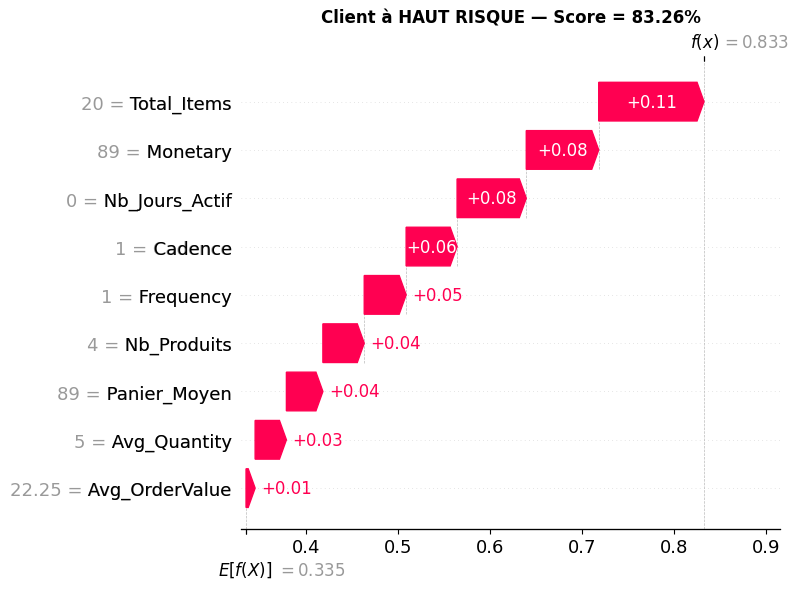

In [11]:
#Waterfall client haut risque
explanation_high = shap.Explanation(
    values=shap_values_churn[high_risk_idx],
    base_values=explainer.expected_value[1],
    data=X.iloc[high_risk_idx],
    feature_names=FEATURE_COLS
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(explanation_high, show=False)
plt.title(f"Client à HAUT RISQUE — Score = "
          f"{features['Churn_Score'].iloc[high_risk_idx]:.2%}",
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/shap_waterfall_high_risk.png',
            dpi=150, bbox_inches='tight')
plt.show()

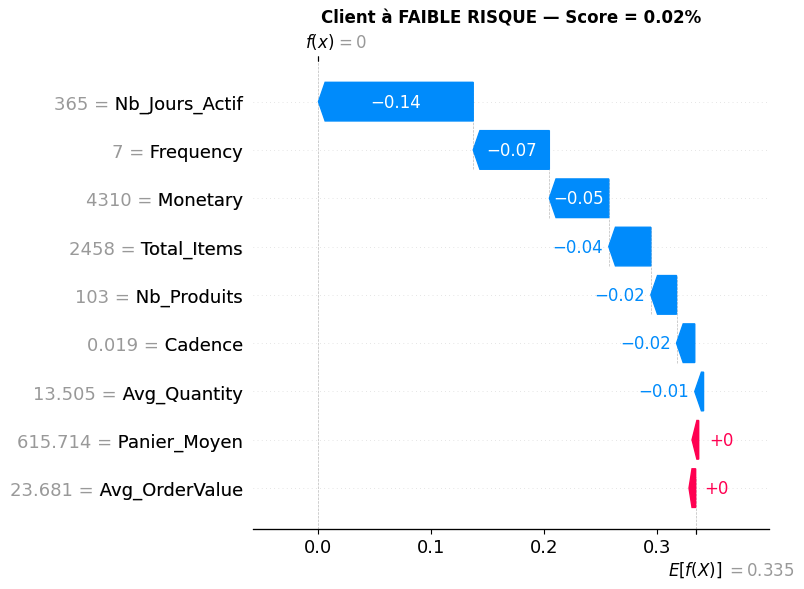

In [12]:
#Waterfall client faible risque
explanation_low = shap.Explanation(
    values=shap_values_churn[low_risk_idx],
    base_values=explainer.expected_value[1],
    data=X.iloc[low_risk_idx],
    feature_names=FEATURE_COLS
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(explanation_low, show=False)
plt.title(f"Client à FAIBLE RISQUE — Score = "
          f"{features['Churn_Score'].iloc[low_risk_idx]:.2%}",
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/shap_waterfall_low_risk.png',
            dpi=150, bbox_inches='tight')
plt.show()

Dependence Plots

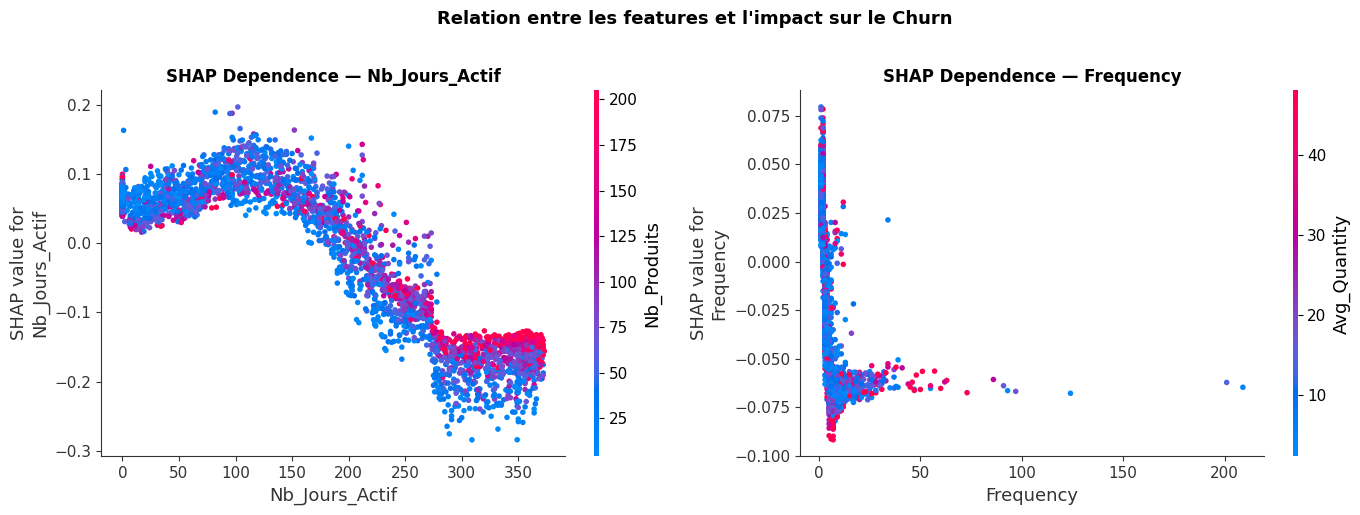

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, feat in enumerate(['Nb_Jours_Actif', 'Frequency']):
    shap.dependence_plot(
        feat,
        shap_values_churn,
        X,
        feature_names=FEATURE_COLS,
        ax=axes[i],
        show=False
    )
    axes[i].set_title(f'SHAP Dependence — {feat}',
                      fontsize=12, fontweight='bold')

plt.suptitle("Relation entre les features et l'impact sur le Churn",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/shap_impact.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [14]:
#Top clients à risque
high_risk_clients = features[
    features['Churn_Score'] > 0.7
][['CustomerID', 'Frequency', 'Monetary',
   'Nb_Jours_Actif', 'Cadence',
   'Churn_Score', 'Churn']].copy()

high_risk_clients = high_risk_clients.sort_values(
    'Churn_Score', ascending=False
).reset_index(drop=True)

high_risk_clients['Priorité'] = high_risk_clients['Churn_Score'].apply(
    lambda x: 'Critique' if x > 0.9
    else 'Élevé' if x > 0.8
    else 'Modéré'
)

print("TOP 15 CLIENTS À HAUT RISQUE DE CHURN")
print(high_risk_clients.head(15).to_string(index=False))
print(f"\nTotal clients haut risque (>70%) : {len(high_risk_clients):,}")

TOP 15 CLIENTS À HAUT RISQUE DE CHURN
 CustomerID  Frequency  Monetary  Nb_Jours_Actif  Cadence  Churn_Score  Churn Priorité
      13391          1     59.80               0      1.0     0.958136      1 Critique
      13302          1     63.75               0      1.0     0.947569      1 Critique
      13747          1     79.60               0      1.0     0.928839      1 Critique
      13185          1     71.40               0      1.0     0.926349      1 Critique
      17747          1     71.40               0      1.0     0.926349      1 Critique
      13682          1     59.50               0      1.0     0.917997      1 Critique
      17960          1     73.78               0      1.0     0.911393      1 Critique
      15668          1     76.32               0      1.0     0.910651      1 Critique
      18113          1     76.32               0      1.0     0.910651      1 Critique
      16148          1     76.32               0      1.0     0.910651      1 Critique
     

In [15]:
# Importance SHAP résumé business
mean_shap = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance_SHAP': np.abs(shap_values_churn).mean(axis=0)
}).sort_values('Importance_SHAP', ascending=False).reset_index(drop=True)

print("IMPORTANCE DES FEATURES (SHAP moyen)")
for _, row in mean_shap.iterrows():
    bar = "█" * int(row['Importance_SHAP'] * 1000)
    print(f"  {row['Feature']:<20} : {row['Importance_SHAP']:.4f} {bar}")

print()
print("INSIGHTS BUSINESS :")
print(f"  1. {mean_shap.iloc[0]['Feature']} → signal le plus fort du churn")
print(f"  2. {mean_shap.iloc[1]['Feature']} → confirme l'engagement financier")
print(f"  3. {mean_shap.iloc[2]['Feature']} → mesure la fidélité comportementale")

🏆 IMPORTANCE DES FEATURES (SHAP moyen)
  Nb_Jours_Actif       : 0.0885 ████████████████████████████████████████████████████████████████████████████████████████
  Monetary             : 0.0396 ███████████████████████████████████████
  Frequency            : 0.0393 ███████████████████████████████████████
  Total_Items          : 0.0388 ██████████████████████████████████████
  Cadence              : 0.0307 ██████████████████████████████
  Nb_Produits          : 0.0288 ████████████████████████████
  Avg_OrderValue       : 0.0146 ██████████████
  Avg_Quantity         : 0.0138 █████████████
  Panier_Moyen         : 0.0123 ████████████

INSIGHTS BUSINESS :
  1. Nb_Jours_Actif → signal le plus fort du churn
  2. Monetary → confirme l'engagement financier
  3. Frequency → mesure la fidélité comportementale


In [16]:
# Cellule 13 — Sauvegarde finale
import joblib
import numpy as np

high_risk_clients.to_csv(
    '../data/processed/clients_haut_risque.csv', index=False
)
np.save('../models/shap_values.npy', shap_values_churn)

Fichiers sauvegardés :
   → data/processed/clients_haut_risque.csv
   → models/shap_values.npy

RÉSUMÉ JOUR 5 — EXPLICABILITÉ SHAP
Graphiques générés :
  → shap_importance.png          (bar chart global)
  → shap_beeswarm.png            (impact détaillé)
  → shap_waterfall_high_risk.png (client 83% churn)
  → shap_waterfall_low_risk.png  (client 0.02% churn)
  → shap_dependence.png          (relations features)
